# Moore-AnimateAnyone — Colab Inference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/goldkangsan/moore-animate-anyone/blob/main/colab_animate_anyone.ipynb)

**Reference Image + Driving Video → Character Animation**

실행 환경: Google Colab (T4 GPU 권장)

---
### 순서
1. GPU 확인
2. 레포 클론 + 패키지 설치
3. Pretrained weights 다운로드
4. 입력 파일 업로드
5. 포즈 추출
6. Animation 생성
7. 결과 영상 확인

## Step 1. GPU 확인

In [1]:
!nvidia-smi
import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total:.1f} GB")

Mon Mar 23 05:20:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2. 레포 클론 + 패키지 설치

> ⚠️ 설치에 5~10분 정도 걸린다.

In [2]:
import os

# Moore-AnimateAnyone 원본 레포 클론
if not os.path.exists("/content/Moore-AnimateAnyone"):
    !git clone https://github.com/MooreThreads/Moore-AnimateAnyone /content/Moore-AnimateAnyone
else:
    print("Already cloned.")

os.chdir("/content/Moore-AnimateAnyone")
print("Working dir:", os.getcwd())

Cloning into '/content/Moore-AnimateAnyone'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 212 (delta 64), reused 45 (delta 45), pack-reused 107 (from 1)
Receiving objects: 100% (212/212), 14.13 MiB | 16.09 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Working dir: /content/Moore-AnimateAnyone


In [3]:
# 패키지 설치
!pip install -q \
    diffusers==0.24.0 \
    transformers==4.30.2 \
    accelerate==0.21.0 \
    einops==0.4.1 \
    omegaconf==2.2.3 \
    av==11.0.0 \
    imageio==2.33.0 \
    imageio-ffmpeg==0.4.9 \
    decord==0.6.0 \
    onnxruntime-gpu==1.16.3 \
    open-clip-torch==2.20.0 \
    scikit-image==0.21.0 \
    tqdm==4.66.1 \
    huggingface_hub

# CLIP (OpenAI)
!pip install -q "clip @ https://github.com/openai/CLIP/archive/d50d76daa670286dd6cacf3bcd80b5e4823fc8e1.zip"

print("\nInstallation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 111.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00

Installation complete.


## Step 3. Pretrained Weights 다운로드

> ⚠️ 총 약 10~15GB. 처음 한 번만 실행하면 된다.  
> Colab 세션이 끊기면 다시 받아야 하므로 Google Drive 마운트를 권장한다.

In [4]:
# (선택) Google Drive 마운트 — weights를 Drive에 저장해두면 세션 재시작 후 재다운 불필요
USE_DRIVE = False  # True로 바꾸면 Drive 마운트

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WEIGHTS_DIR = "/content/drive/MyDrive/animateanyone_weights"
    import os
    os.makedirs(WEIGHTS_DIR, exist_ok=True)
    # symlink로 연결
    if not os.path.exists("/content/Moore-AnimateAnyone/pretrained_weights"):
        os.symlink(WEIGHTS_DIR, "/content/Moore-AnimateAnyone/pretrained_weights")
    print(f"Weights dir: {WEIGHTS_DIR}")
else:
    print("Using local /content/Moore-AnimateAnyone/pretrained_weights")

Using local /content/Moore-AnimateAnyone/pretrained_weights


In [5]:
import os
os.chdir("/content/Moore-AnimateAnyone")

# weights 다운로드 실행
!python tools/download_weights.py

Preparing base stable-diffusion-v1-5 weights...
config.json: 100% 743/743 [00:00<00:00, 2.50MB/s]
unet/diffusion_pytorch_model.bin: 100% 3.44G/3.44G [00:42<00:00, 80.9MB/s]
Preparing image encoder weights...
config.json: 100% 703/703 [00:00<00:00, 4.90MB/s]
image_encoder/pytorch_model.bin: 100% 1.22G/1.22G [00:07<00:00, 173MB/s]
Preparing DWPose weights...
./dw-ll_ucoco_384.onnx: 100% 134M/134M [00:01<00:00, 83.5MB/s]
./yolox_l.onnx: 100% 217M/217M [00:01<00:00, 135MB/s] 
Preparing vae weights...
config.json: 100% 547/547 [00:00<00:00, 2.77MB/s]
./diffusion_pytorch_model.bin: 100% 335M/335M [00:04<00:00, 69.6MB/s]
Preparing AnimateAnyone weights...
./denoising_unet.pth: 100% 3.44G/3.44G [00:35<00:00, 96.5MB/s]
./motion_module.pth: 100% 1.82G/1.82G [00:20<00:00, 89.1MB/s]
./pose_guider.pth: 100% 4.35M/4.35M [00:00<00:00, 7.08MB/s]
./reference_unet.pth: 100% 3.44G/3.44G [00:30<00:00, 115MB/s]


## Step 4. 입력 파일 업로드

- **Reference Image**: 애니메이션할 사람 이미지 (PNG/JPG)
- **Driving Video**: 동작 영상 (MP4 권장)

In [6]:
from google.colab import files
import shutil, os

os.makedirs("/content/Moore-AnimateAnyone/inputs", exist_ok=True)

print("Reference image를 업로드하세요 (PNG/JPG):")
uploaded = files.upload()
for fname in uploaded:
    dest = f"/content/Moore-AnimateAnyone/inputs/{fname}"
    with open(dest, "wb") as f:
        f.write(uploaded[fname])
    REF_IMAGE = dest
    print(f"  Saved: {dest}")

Reference image를 업로드하세요 (PNG/JPG):


Saving anyone-10.png to anyone-10.png
  Saved: /content/Moore-AnimateAnyone/inputs/anyone-10.png


In [7]:
print("Driving video를 업로드하세요 (MP4):")
uploaded = files.upload()
for fname in uploaded:
    dest = f"/content/Moore-AnimateAnyone/inputs/{fname}"
    with open(dest, "wb") as f:
        f.write(uploaded[fname])
    DRIVING_VIDEO = dest
    print(f"  Saved: {dest}")

Driving video를 업로드하세요 (MP4):


Saving anyone-video-2_kps.mp4 to anyone-video-2_kps.mp4
  Saved: /content/Moore-AnimateAnyone/inputs/anyone-video-2_kps.mp4


Reference image : /content/Moore-AnimateAnyone/inputs/anyone-10.png
Driving video   : /content/Moore-AnimateAnyone/inputs/anyone-video-2_kps.mp4
Image size      : (614, 847)


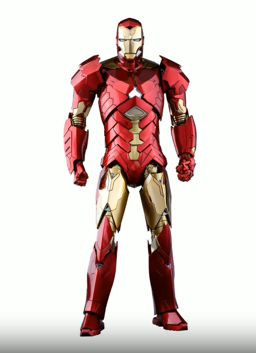

In [8]:
# 입력 확인
from PIL import Image
import IPython.display as ipd

print(f"Reference image : {REF_IMAGE}")
print(f"Driving video   : {DRIVING_VIDEO}")

img = Image.open(REF_IMAGE)
print(f"Image size      : {img.size}")
ipd.display(img.resize((256, int(256 * img.size[1] / img.size[0]))))

## Step 5. 입력 전처리 + 포즈 추출

In [9]:
import os
os.chdir("/content/Moore-AnimateAnyone")

# 해상도 설정
WIDTH  = 512
HEIGHT = 784

# Reference image 리사이즈/크롭
from PIL import Image

def resize_and_crop(image, target_w, target_h):
    orig_w, orig_h = image.size
    target_ratio = target_w / target_h
    orig_ratio   = orig_w / orig_h
    if orig_ratio > target_ratio:
        new_w = int(orig_h * target_ratio)
        left  = (orig_w - new_w) // 2
        image = image.crop((left, 0, left + new_w, orig_h))
    else:
        new_h = int(orig_w / target_ratio)
        top   = (orig_h - new_h) // 2
        image = image.crop((0, top, orig_w, top + new_h))
    return image.resize((target_w, target_h), Image.LANCZOS)

img = Image.open(REF_IMAGE).convert("RGB")
img_resized = resize_and_crop(img, WIDTH, HEIGHT)
REF_PROCESSED = "/content/Moore-AnimateAnyone/inputs/ref.png"
img_resized.save(REF_PROCESSED)
print(f"Ref image saved: {REF_PROCESSED}  ({img_resized.size})")

Ref image saved: /content/Moore-AnimateAnyone/inputs/ref.png  ((512, 784))


In [10]:
# 포즈 추출 (DWPose)
import os
from pathlib import Path

video_name = Path(DRIVING_VIDEO).stem
POSE_VIDEO = f"/content/Moore-AnimateAnyone/inputs/{video_name}_kps.mp4"

!python tools/vid2pose.py \
    --video_path "{DRIVING_VIDEO}" \
    --output_path "{POSE_VIDEO}"

print(f"\nPose video: {POSE_VIDEO}")

Traceback (most recent call last):
  File "/content/Moore-AnimateAnyone/tools/vid2pose.py", line 1, in <module>
    from src.dwpose import DWposeDetector
ModuleNotFoundError: No module named 'src'

Pose video: /content/Moore-AnimateAnyone/inputs/anyone-video-2_kps_kps.mp4


In [14]:
# 포즈 비디오 미리보기
from IPython.display import Video
Video(POSE_VIDEO, width=300, embed=True)

ValueError: To embed videos, you must pass embed=True (this may make your notebook files huge)
Consider passing Video(url='...')

## Step 6. Animation 생성

| 파라미터 | 설명 | 권장값 |
|----------|------|--------|
| WIDTH/HEIGHT | 출력 해상도 | 512x784 (T4 기준) |
| N_FRAMES | 생성 프레임 수 | 32~64 |
| STEPS | DDIM steps | 30 |
| CFG | guidance scale | 3.5 |

In [ ]:
# config 업데이트
from omegaconf import OmegaConf

cfg = OmegaConf.load("./configs/prompts/animation.yaml")
cfg["test_cases"] = {REF_PROCESSED: [POSE_VIDEO]}
OmegaConf.save(cfg, "./configs/prompts/animation.yaml")
print("animation.yaml updated.")
print(OmegaConf.to_yaml(cfg))

In [ ]:
# 생성 파라미터
WIDTH    = 512
HEIGHT   = 784
N_FRAMES = 32    # VRAM 부족하면 16으로 낮춰라
STEPS    = 30
CFG      = 3.5
SEED     = 42

!python scripts/pose2vid.py \
    --config ./configs/prompts/animation.yaml \
    -W {WIDTH} -H {HEIGHT} -L {N_FRAMES} \
    --steps {STEPS} --cfg {CFG} --seed {SEED}

## Step 7. 결과 확인 및 다운로드

In [ ]:
import glob
from IPython.display import Video

# 가장 최근 생성된 mp4 찾기
results = sorted(glob.glob("/content/Moore-AnimateAnyone/output/**/*.mp4", recursive=True))
if results:
    latest = results[-1]
    print(f"결과 파일: {latest}")
    Video(latest, width=700)
else:
    print("결과 파일이 없습니다. Step 6을 다시 실행해주세요.")

In [ ]:
# 결과 다운로드
from google.colab import files

if results:
    files.download(results[-1])
    print(f"Downloading: {results[-1]}")

---
## 트러블슈팅

**CUDA out of memory**
```python
N_FRAMES = 16
WIDTH, HEIGHT = 384, 512
```

**포즈 추출 실패**
- DWPose weights 확인: `pretrained_weights/DWPose/*.onnx`
- 비디오 포맷: H.264 MP4 권장

**결과가 흔들리거나 품질이 낮을 때**
- `CFG` 값을 3.5 → 5.0으로 올려라
- `STEPS`를 30 → 50으로 올려라
- Reference image 품질 확인 (배경 단순, 전신 포함 권장)